In [1]:
import tifffile as tiff
import imagecodecs as imagecodecs

import openslide as openslide
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import imageio.v3 as iio
import numpy as np
import os
from PIL import Image

In [2]:
DATA_PATH = "/Volumes/LabData/BMED6460/beetle-master/data/"

(147019, 135975) uint8


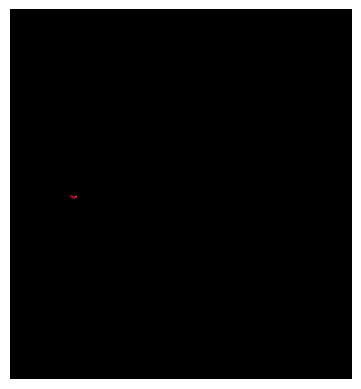

In [6]:
mask = tiff.imread(DATA_PATH + "/annotations/masks/patient1_wsi1.tif")
print(mask.shape, mask.dtype)

colors = [
    (0, 0, 0),        # 0: unannotated black
    (1, 0, 0),        # 1: other red
    (0, 1, 0),        # 2: non-invasive green
    (0, 0, 1),        # 3: invasive blue
    (1, 1, 0),        # 4: necrosis yellow
]

cmap = ListedColormap(colors)

# Downsample
mask_small = mask[::16, ::16]

plt.imshow(mask_small,cmap=cmap, vmin=0, vmax=4)
plt.axis("off")
# plt.colorbar(ticks=[0,1,2,3,4])
plt.show()

(135975, 147019)
((135975, 147019), (67987, 73509), (33993, 36754), (16996, 18377), (8498, 9188), (4249, 4594), (2124, 2297), (1062, 1148), (531, 574), (265, 287), (132, 143), (66, 71))


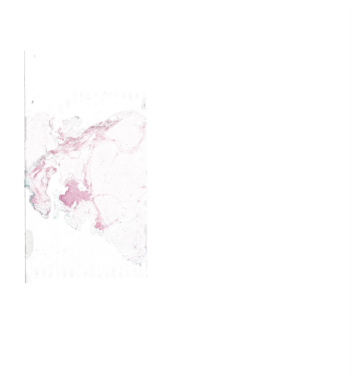

In [7]:
slide = openslide.OpenSlide(DATA_PATH + "images/development/wsis/patient1_wsi1.tif")
print(slide.dimensions)
w, h = slide.dimensions
# region = slide.read_region((w//2, h//2), 0, (512, 512))

print(slide.level_dimensions)

level = slide.level_count - 6
downsample_factor = slide.level_downsamples[level]
x = int(800 * downsample_factor)
y = int(700 * downsample_factor)
width = int(100 * downsample_factor)  # 900 - 800
height = int(100 * downsample_factor)  # 800 - 700

region = slide.read_region((0, 0), level, slide.level_dimensions[level])
# region = slide.read_region((x, y), level, (width, height))

region = region.convert("RGB")

plt.imshow(region)
plt.axis('off')
plt.show()

(2048, 2048, 3)


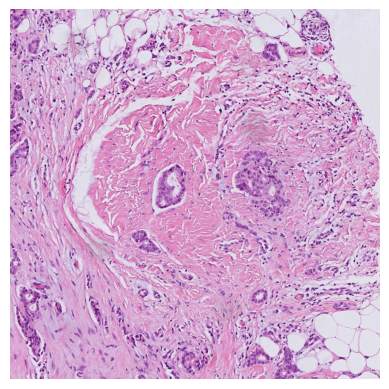

In [5]:
img = iio.imread(DATA_PATH + "images/evaluation/rois/patient320_wsi1_roi1.png")

print(img.shape)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
wsi_extraction \
  --wsi_paths /Volumes/LabData/BMED6460/beetle-master/data/images/development/wsis/patient1_wsi1.tif \
  --annotation_paths /Volumes/LabData/BMED6460/beetle-master/data/annotations/jsons/patient1_wsi1.json \
  --patch_size 256 \
  --save_only_annotated_patches \
  --store_masks \
  --min_intersection_ratio 0.1 \
  --incomplete_annotations \
  --output_path /Volumes/LabData/BMED6460/beetle-master/data/images/development/output

In [ ]:
# --- parameters ---
PATCH_SIZE = 2048
STRIDE = 2048   # can set < PATCH_SIZE for overlap
MIN_ANNOT_PIXELS = 0.05  # keep patch if >=5% annotated

wsi_path = DATA_PATH + "images/development/wsis/patient1_wsi1.tif"
mask_path = DATA_PATH + "annotations/masks/patient1_wsi1.tif"
out_dir = DATA_PATH + "images/development/wsis"

os.makedirs(out_dir, exist_ok=True)

In [ ]:
# --- load data ---
slide = openslide.OpenSlide(wsi_path)
mask = tiff.imread(mask_path)  # shape: (H, W)

width, height = slide.dimensions

patch_id = 0

for y in range(0, height - PATCH_SIZE + 1, STRIDE):
    for x in range(0, width - PATCH_SIZE + 1, STRIDE):

        # --- get mask patch ---
        mask_patch = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

        # skip mostly unannotated patches
        annotated_fraction = np.mean(mask_patch > 0)
        if annotated_fraction < MIN_ANNOT_PIXELS:
            continue

        # --- get WSI patch ---
        wsi_patch = slide.read_region((x, y), 0, (PATCH_SIZE, PATCH_SIZE))
        wsi_patch = wsi_patch.convert("RGB")  # remove alpha

        # --- save ---
        wsi_patch.save(os.path.join(out_dir, f"img_{patch_id}.png"))
        Image.fromarray(mask_patch.astype(np.uint8)).save(
            os.path.join(out_dir, f"mask_{patch_id}.png")
        )

        patch_id += 1

print(f"Saved {patch_id} patches.")